In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Salary.csv')

In [3]:
df.shape

(2000, 4)

In [4]:
df.head()

,Age,YearsExperience,EducationLevel,Salary
0,28,1,Master,56512
1,35,8,Master,91587
2,55,5,Bachelor,70520
3,22,1,Bachelor,47779
4,59,1,Bachelor,69731


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Age              2000 non-null   int64 
 1   YearsExperience  2000 non-null   int64 
 2   EducationLevel   2000 non-null   object
 3   Salary           2000 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 62.6+ KB


In [6]:
df.isnull().sum()

Age                0
YearsExperience    0
EducationLevel     0
Salary             0
dtype: int64

In [7]:
df.describe()

,Age,YearsExperience,Salary
count,2000.000000,2000.000000,2000.00000
mean,41.077000,12.942000,102088.64850
std,11.460442,9.519241,37867.63088
min,21.000000,0.000000,29100.00000
25%,31.000000,5.000000,71000.75000
50%,41.000000,11.000000,96387.00000
75%,51.000000,20.000000,129868.00000
max,60.000000,39.000000,221269.00000


In [8]:
df_cleaned = df.drop_duplicates(inplace = True)

In [9]:
df.shape

(1999, 4)

In [14]:
df.columns

Index(['Age', 'YearsExperience', 'EducationLevel', 'Salary'], dtype='object')

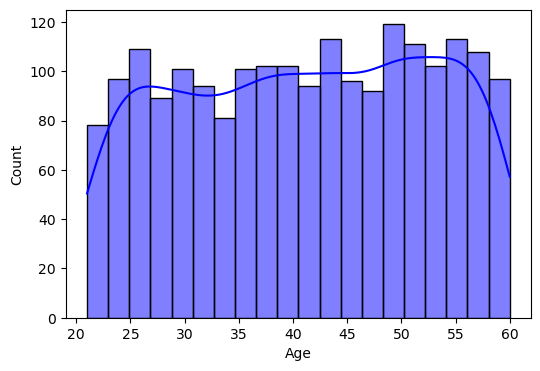

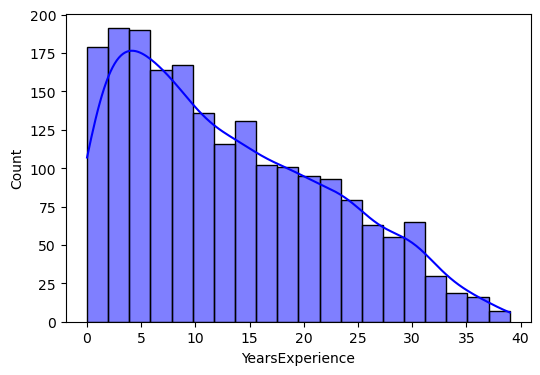

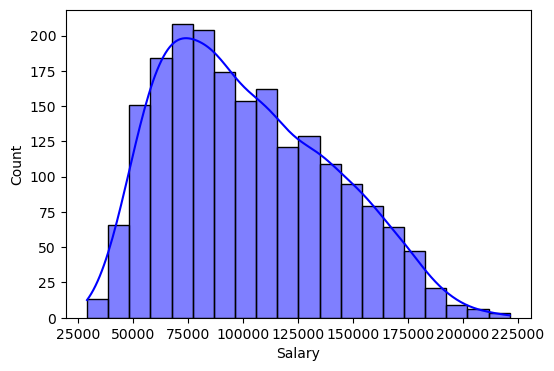

In [19]:
numerical_col = ['Age', 'YearsExperience', 'Salary']
for col in numerical_col:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde = True, bins=20, color = 'blue')

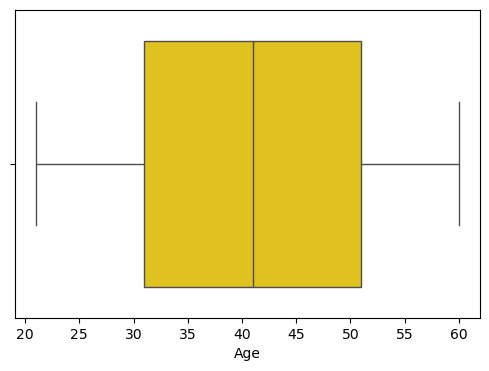

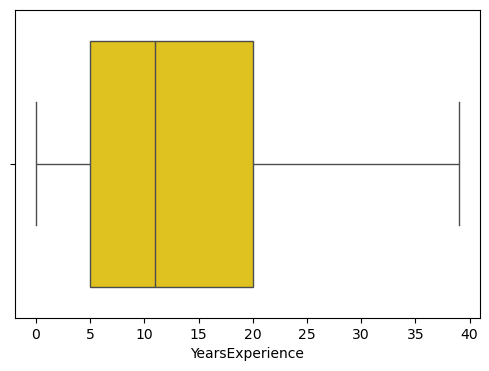

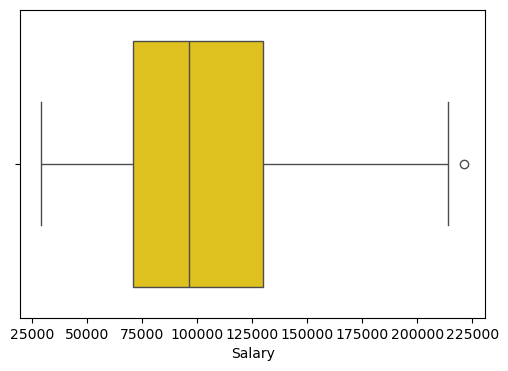

In [26]:
numerical_col = ['Age', 'YearsExperience', 'Salary']
for col in numerical_col:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col],color='gold')

<Axes: >

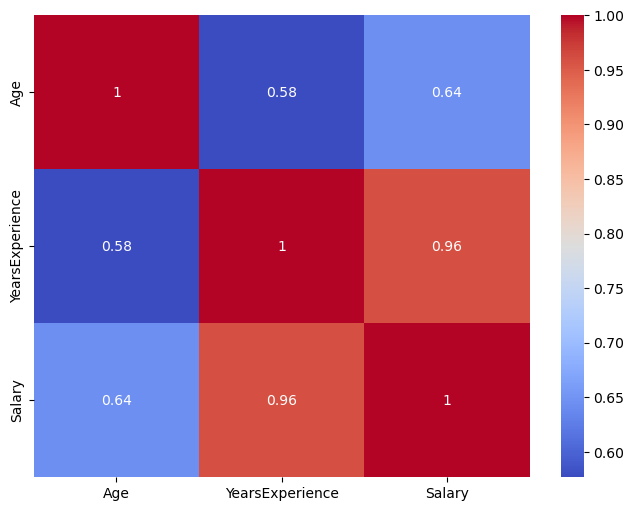

In [28]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot = True, cmap = 'coolwarm')

In [35]:
df.columns

Index(['Age', 'YearsExperience', 'Salary', 'EducationLevel_HighSchool',
       'EducationLevel_Master', 'EducationLevel_PhD'],
      dtype='object')

In [37]:
df.head()

,Age,YearsExperience,Salary,EducationLevel_HighSchool,EducationLevel_Master,EducationLevel_PhD
0,28,1,56512,False,True,False
1,35,8,91587,False,True,False
2,55,5,70520,False,False,False
3,22,1,47779,False,False,False
4,59,1,69731,False,False,False


In [38]:
df = df.astype(int)

In [39]:
df.head()

,Age,YearsExperience,Salary,EducationLevel_HighSchool,EducationLevel_Master,EducationLevel_PhD
0,28,1,56512,0,1,0
1,35,8,91587,0,1,0
2,55,5,70520,0,0,0
3,22,1,47779,0,0,0
4,59,1,69731,0,0,0


In [43]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
cols=['Age', 'YearsExperience']               #standerd scalling for getting better results
scaler= StandardScaler()            

df[cols]=scaler.fit_transform(df[cols])

In [44]:
df.head()

,Age,YearsExperience,Salary,EducationLevel_HighSchool,EducationLevel_Master,EducationLevel_PhD
0,-1.141210,-1.254356,56512,0,1,0
1,-0.530403,-0.518969,91587,0,1,0
2,1.214762,-0.834135,70520,0,0,0
3,-1.664760,-1.254356,47779,0,0,0
4,1.563795,-1.254356,69731,0,0,0


In [46]:
x = df.drop('Salary', axis =1)
y = df['Salary']

In [47]:
from sklearn.model_selection import train_test_split

In [48]:
 x_train, x_test, y_train, y_test = train_test_split( x, y, test_size=0.20, random_state=42)

In [51]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [52]:
y_pred = model.predict(x_test)

In [58]:
print("R2 Score :", r2_score(y_test, y_pred))
print("MAE      :", mean_absolute_error(y_test, y_pred))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score : 0.9876690014433999
MAE      : 3858.093082697039
RMSE     : 4451.280499113569
